<a href="https://colab.research.google.com/github/giseleoliver9/Analise_Exploratoria_de_Vendas_de_Video_Games/blob/main/An%C3%A1lise_Explorat%C3%B3ria_de_Vendas_de_Video_Games.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Análise Exploratória de Vendas de Video Games**

DATASET: https://www.kaggle.com/datasets/rush4ratio/video-game-sales-with-ratings

Este projeto tem como objetivo aplicar os fundamentos da Ciência de Dados, com foco na Análise Exploratória de Dados (EDA), usando um dataset real sobre vendas globais de jogos. Serão utilizados conceitos como variáveis categóricas, histogramas, boxplots e as bibliotecas Pandas, Numpy, Matplotlib e Seaborn.




#Importação das bibliotecas e informação dos dados



In [ ]:
# Bibliotecas principais
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Estilo dos gráficos
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (10,6)




In [ ]:
from google.colab import files
files.upload()

Saving Video_Games_Sales_as_at_22_Dec_2016.csv to Video_Games_Sales_as_at_22_Dec_2016.csv


{'Video_Games_Sales_as_at_22_Dec_2016.csv': b'Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating\r\nWii Sports,Wii,2006,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76,51,8,322,Nintendo,E\r\nSuper Mario Bros.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,,,,,,\r\nMario Kart Wii,Wii,2008,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82,73,8.3,709,Nintendo,E\r\nWii Sports Resort,Wii,2009,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80,73,8,192,Nintendo,E\r\nPokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1,31.37,,,,,,\r\nTetris,GB,1989,Puzzle,Nintendo,23.2,2.26,4.22,0.58,30.26,,,,,,\r\nNew Super Mario Bros.,DS,2006,Platform,Nintendo,11.28,9.14,6.5,2.88,29.8,89,65,8.5,431,Nintendo,E\r\nWii Play,Wii,2006,Misc,Nintendo,13.96,9.18,2.93,2.84,28.92,58,41,6.6,129,Nintendo,E\r\nNew Super Mario Bros. Wii,Wii,2009,Platform,Nintendo,14.44,6.94,4.7,2.24,28.32,87

### Dicionário dos Dados

- Name: Nome do jogo (String)
- Platform: Plataforma em que foi lançado (String)
- Year_of_Release: Ano de lançamento (Float)
- Genre: Gênero do jogo (String)
- Publisher: Publicadora (String)
- NA_Sales: Vendas na América do Norte (Float, em milhões)
- EU_Sales: Vendas na Europa (Float, em milhões)
- JP_Sales: Vendas no Japão (Float, em milhões)
- Other_Sales: Vendas em outras regiões (Float, em milhões)
- Global_Sales: Vendas globais (Float, soma total)
- Critic_Score: Nota média da crítica (Float, 0-100)
- Critic_Count: Número de avaliações da crítica (Float)
- User_Score: Nota média dos usuários (Float, 0-10)
- User_Count: Número de avaliações dos usuários (Float)
- Developer: Desenvolvedora do jogo (String)
- Rating: Classificação etária (String, Ex: E, M, T)

In [ ]:
# 5 primeiras informações do dataset com linhas e colunas
df = pd.read_csv('Video_Games_Sales_as_at_22_Dec_2016.csv')
df.head()


,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,Wii Sports,Wii,2006.0,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8,322.0,Nintendo,E
1,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,Nintendo,E
3,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8,192.0,Nintendo,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Informações básicas do dataset: mostra os tipos de dados, valores nulos e colunas.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16719 entries, 0 to 16718
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16717 non-null  object 
 1   Platform         16719 non-null  object 
 2   Year_of_Release  16450 non-null  float64
 3   Genre            16717 non-null  object 
 4   Publisher        16665 non-null  object 
 5   NA_Sales         16719 non-null  float64
 6   EU_Sales         16719 non-null  float64
 7   JP_Sales         16719 non-null  float64
 8   Other_Sales      16719 non-null  float64
 9   Global_Sales     16719 non-null  float64
 10  Critic_Score     8137 non-null   float64
 11  Critic_Count     8137 non-null   float64
 12  User_Score       10015 non-null  object 
 13  User_Count       7590 non-null   float64
 14  Developer        10096 non-null  object 
 15  Rating           9950 non-null   object 
dtypes: float64(9), object(7)
memory usage: 2.0+ MB


In [ ]:
# Estatísticas descritivas
df.describe()

,Year_of_Release,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Count
count,16450.000000,16719.000000,16719.000000,16719.000000,16719.000000,16719.000000,8137.000000,8137.000000,7590.000000
mean,2006.487356,0.263330,0.145025,0.077602,0.047332,0.533543,68.967679,26.360821,162.229908
std,5.878995,0.813514,0.503283,0.308818,0.186710,1.547935,13.938165,18.980495,561.282326
min,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000,13.000000,3.000000,4.000000
25%,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000,60.000000,12.000000,10.000000
50%,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000,71.000000,21.000000,24.000000
75%,2010.000000,0.240000,0.110000,0.040000,0.030000,0.470000,79.000000,36.000000,81.000000
max,2020.000000,41.360000,28.960000,10.220000,10.570000,82.530000,98.000000,113.000000,10665.000000


In [ ]:
# Verificando colunas únicas
print("Gêneros:", df['Genre'].unique())
print("\nClassificações (Rating):", df['Rating'].unique())


Gêneros: ['Sports' 'Platform' 'Racing' 'Role-Playing' 'Puzzle' 'Misc' 'Shooter'
 'Simulation' 'Action' 'Fighting' 'Adventure' 'Strategy' nan]

Classificações (Rating): ['E' nan 'M' 'T' 'E10+' 'K-A' 'AO' 'EC' 'RP']


# Limpeza dos Dados



In [ ]:
# Verificando valores nulos
df.isnull().sum()


,0
Name,2
Platform,0
Year_of_Release,269
Genre,2
Publisher,54
NA_Sales,0
EU_Sales,0
JP_Sales,0
Other_Sales,0
Global_Sales,0


In [ ]:
# Remoção das linhas com valores nulos
df_clean = df.dropna()

df_clean.isnull().sum()


,0
Name,0
Platform,0
Year_of_Release,0
Genre,0
Publisher,0
NA_Sales,0
EU_Sales,0
JP_Sales,0
Other_Sales,0
Global_Sales,0


# Análise Exploratória e Visualizações




Venda de jogos por região

In [ ]:
df.columns

Index(['Name', 'Platform', 'Year_of_Release', 'Genre', 'Publisher', 'NA_Sales',
       'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales', 'Critic_Score',
       'Critic_Count', 'User_Score', 'User_Count', 'Developer', 'Rating'],
      dtype='object')

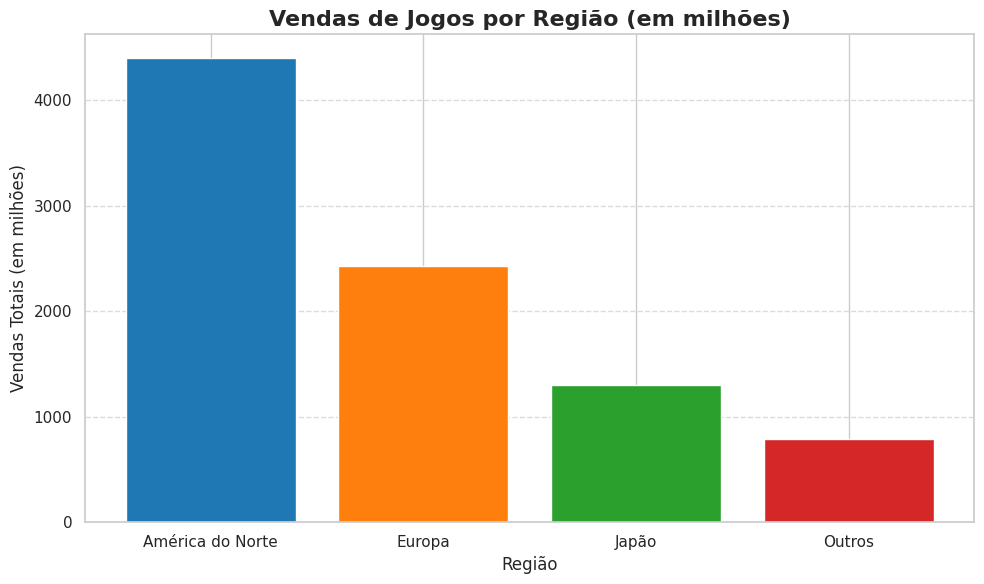

In [ ]:
# Somando as vendas por região
region_sales = {
    'América do Norte': df['NA_Sales'].sum(),
    'Europa': df['EU_Sales'].sum(),
    'Japão': df['JP_Sales'].sum(),
    'Outros': df['Other_Sales'].sum()
}

# Plot
plt.figure(figsize=(10, 6))
plt.bar(region_sales.keys(), region_sales.values(), color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])

plt.title('Vendas de Jogos por Região (em milhões)', fontsize=16, fontweight='bold')
plt.ylabel('Vendas Totais (em milhões)', fontsize=12)
plt.xlabel('Região', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


### Publishers por vendas globais

In [ ]:
# Top 10 publishers por vendas globais
df_clean.groupby('Publisher')['Global_Sales'] \
        .sum() \
        .sort_values(ascending=False) \
        .head(10)


,Global_Sales
Publisher,
Electronic Arts,868.55
Nintendo,849.49
Activision,535.74
Sony Computer Entertainment,388.10
Take-Two Interactive,350.17
Ubisoft,340.23
Microsoft Game Studios,216.49
THQ,162.87
Sega,148.42


<ipython-input-13-3286321835>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sales, y=publishers, palette="magma")


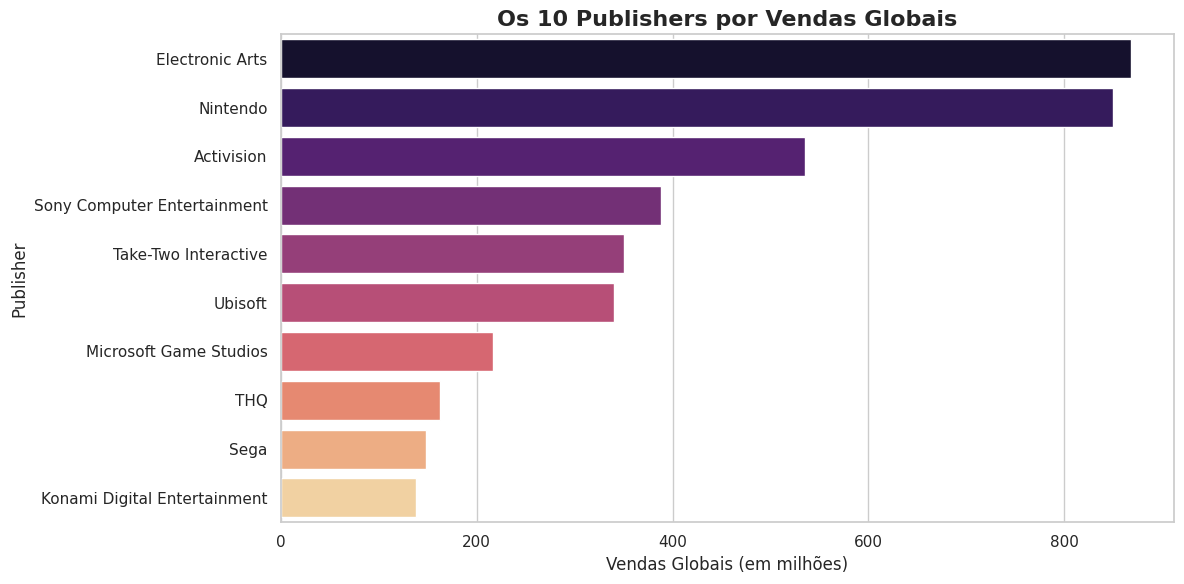

In [ ]:
# Dados
publishers = [
    'Electronic Arts', 'Nintendo', 'Activision', 'Sony Computer Entertainment',
    'Take-Two Interactive', 'Ubisoft', 'Microsoft Game Studios', 'THQ',
    'Sega', 'Konami Digital Entertainment'
]
sales = [868.55, 849.49, 535.74, 388.10, 350.17, 340.23, 216.49, 162.87, 148.42, 137.87]

# Plot
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

sns.barplot(x=sales, y=publishers, palette="magma")

plt.title('Os 10 Publishers por Vendas Globais', fontsize=16, fontweight='bold')
plt.xlabel('Vendas Globais (em milhões)', fontsize=12)
plt.ylabel('Publisher', fontsize=12)

plt.tight_layout()
plt.show()


- Electronic Arts e Nintendo lideram com margens bem próximas — quase 870 milhões cada.

- Activision, conhecido por franquias como Call of Duty, também ocupa um lugar forte no ranking.

- Sony e Microsoft, embora gigantes da indústria, aparecem abaixo de publishers third-party como Take-Two e Ubisoft.

- Publishers japoneses como Sega e Konami ainda estão no top 10, mas com vendas menores.

### Jogos por Plataforma

In [ ]:
# Quantidade de jogos por plataforma (jogos que tiveram vendas registradas)
df_clean['Platform'].value_counts()


,count
Platform,
PS2,1140
X360,858
PS3,769
PC,651
XB,565
Wii,479
DS,464
PSP,390
GC,348


<ipython-input-15-2063352952>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts, y=platforms, palette="cubehelix")


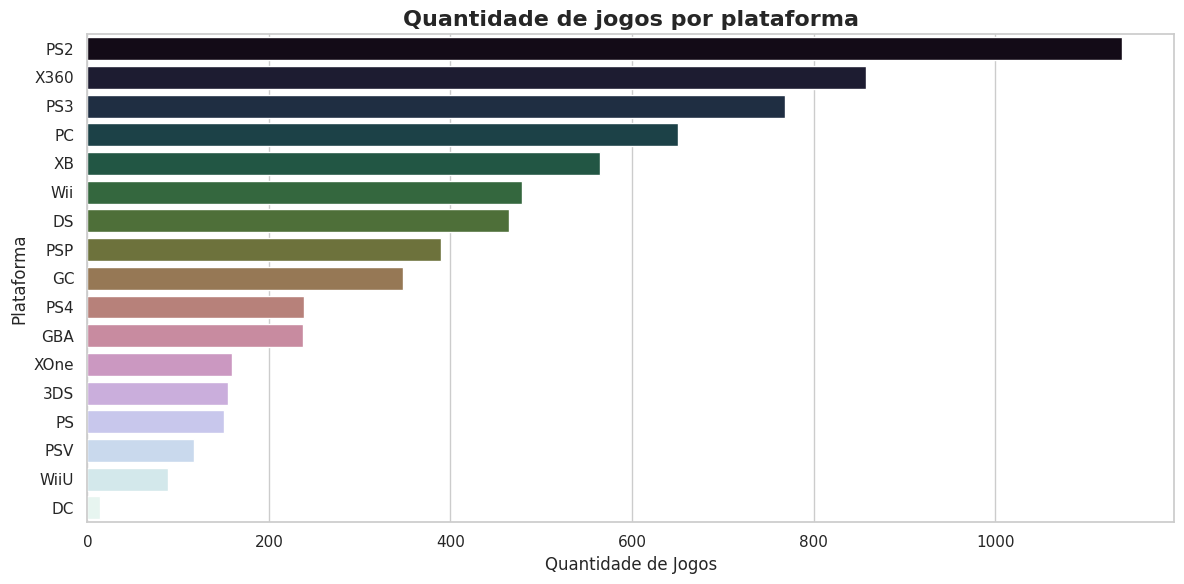

In [ ]:
# Dados
platforms = ['PS2', 'X360', 'PS3', 'PC', 'XB', 'Wii', 'DS', 'PSP', 'GC',
             'PS4', 'GBA', 'XOne', '3DS', 'PS', 'PSV', 'WiiU', 'DC']
counts = [1140, 858, 769, 651, 565, 479, 464, 390, 348,
          239, 237, 159, 155, 150, 118, 89, 14]

# Plot
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

sns.barplot(x=counts, y=platforms, palette="cubehelix")

plt.title('Quantidade de jogos por plataforma', fontsize=16, fontweight='bold')
plt.xlabel('Quantidade de Jogos', fontsize=12)
plt.ylabel('Plataforma', fontsize=12)

plt.tight_layout()
plt.show()


- PS2 lidera com folga, com mais de 1.100 jogos, mostrando por que é considerada uma das plataformas mais bem-sucedidas da história.

- Xbox 360 e PS3 vêm logo atrás, refletindo a geração de consoles com muitos lançamentos.

- PC tem forte presença, mesmo sendo uma plataforma sem geração específica — reforça sua longevidade e versatilidade.

- Plataformas como Dreamcast (DC) e Wii U aparecem no final, indicando ciclos de vida mais curtos ou menor apoio de desenvolved

### Maior média de Critic Score

In [ ]:
#Ano com maior média de Critic_Score
df_clean.dropna(subset=['Year_of_Release', 'Critic_Score']) \
        .groupby('Year_of_Release')['Critic_Score'] \
        .mean() \
        .sort_values(ascending=False) \
        .head(5)


,Critic_Score
Year_of_Release,
1996.0,89.428571
1997.0,86.153846
1992.0,85.000000
1999.0,81.400000
1998.0,81.280000


<ipython-input-17-309881114>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_avg_critic_score.index.astype(int), y=df_avg_critic_score.values, palette="Blues_d")


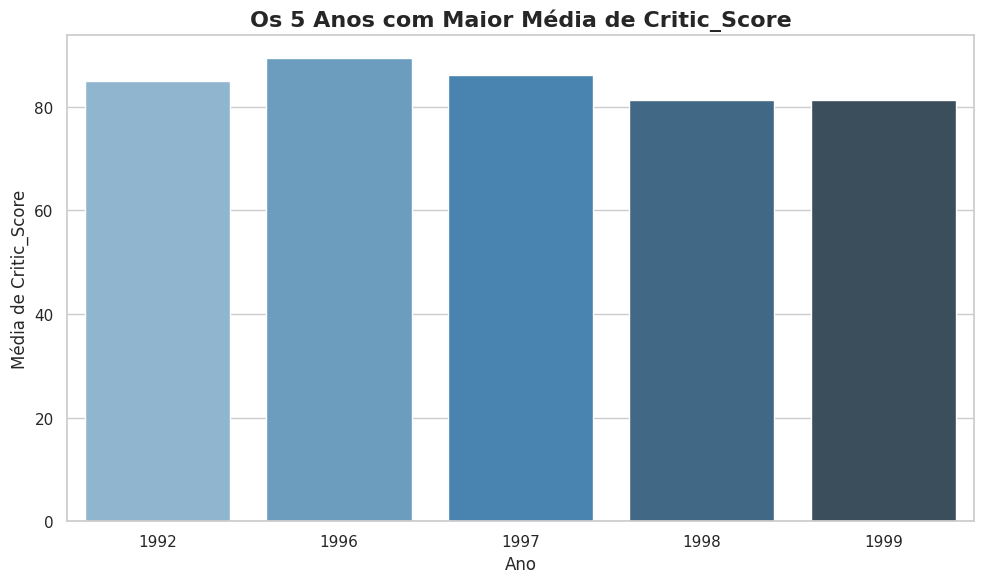

In [ ]:
# Filtrar dados e calcular a média de Critic_Score por ano
df_avg_critic_score = df_clean.dropna(subset=['Year_of_Release', 'Critic_Score']) \
        .groupby('Year_of_Release')['Critic_Score'] \
        .mean() \
        .sort_values(ascending=False) \
        .head(5)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=df_avg_critic_score.index.astype(int), y=df_avg_critic_score.values, palette="Blues_d")

# Títulos e rótulos
plt.title('Os 5 Anos com Maior Média de Critic_Score', fontsize=16, fontweight='bold')
plt.xlabel('Ano', fontsize=12)
plt.ylabel('Média de Critic_Score', fontsize=12)
plt.tight_layout()
plt.show()


Anos com as maiores médias de avaliação da crítica (Critic_Score)

- 1996 foi o ano com a melhor média de nota da crítica (89.43) — isso pode refletir um período com menos lançamentos, mas com alta qualidade, ou a chegada de títulos icônicos.

- Anos 1992, 1997 a 1999 também se destacam, indicando um período forte de lançamentos bem avaliados, provavelmente relacionado ao auge de consoles como Super Nintendo, Nintendo 64 e PlayStation 1.

- Pode indicar que menos jogos com mais qualidade impactavam positivamente a média.

### Plataformas com os jogos mais bem avaliados

In [ ]:
# Top 5 plataformas em que os jogos mais bem avaliados pela crítica são
df_clean.dropna(subset=['Critic_Score']) \
        .groupby('Platform')['Critic_Score'] \
        .mean() \
        .sort_values(ascending=False) \
        .head(5)

,Critic_Score
Platform,
DC,87.357143
PC,76.261137
PS,73.853333
XOne,73.729560
PS4,72.669456


<ipython-input-19-2153161149>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_platforms_critic_score.values, y=top_platforms_critic_score.index, palette="viridis")


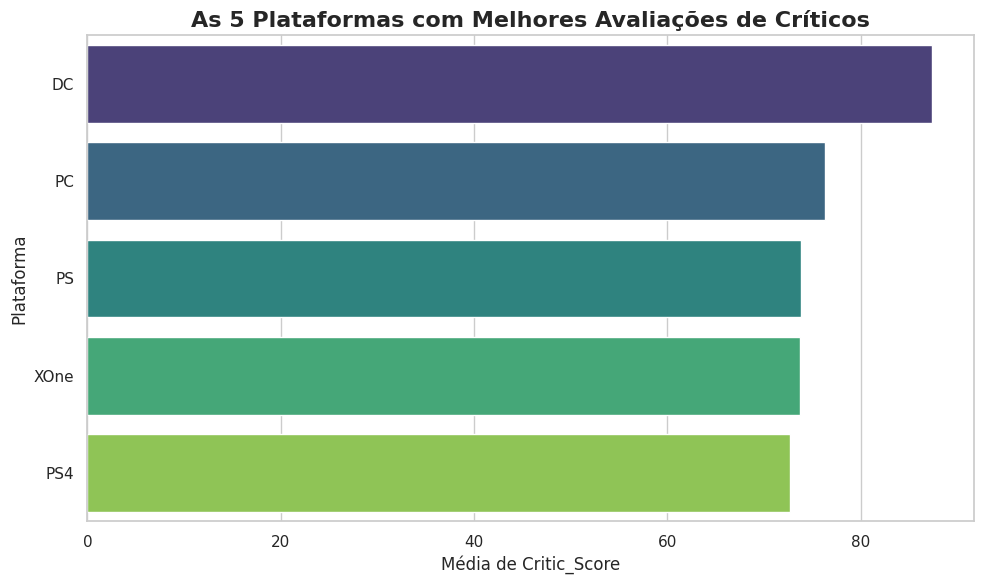

In [ ]:
# Calcular a média de Critic_Score por plataforma
top_platforms_critic_score = df_clean.dropna(subset=['Critic_Score']) \
        .groupby('Platform')['Critic_Score'] \
        .mean() \
        .sort_values(ascending=False) \
        .head(5)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=top_platforms_critic_score.values, y=top_platforms_critic_score.index, palette="viridis")

# Títulos e rótulos
plt.title('As 5 Plataformas com Melhores Avaliações de Críticos', fontsize=16, fontweight='bold')
plt.xlabel('Média de Critic_Score', fontsize=12)
plt.ylabel('Plataforma', fontsize=12)
plt.tight_layout()
plt.show()


- Dreamcast (DC) tem a melhor média de avaliação (87.36), apesar de sua curta vida útil, indicando que os críticos apreciaram seus jogos cultuados e inovadores.

- PC (76.26) tem uma avaliação alta devido à sua diversidade de jogos, desde grandes lançamentos até indie, com forte ênfase em personalização e desempenho.

- PlayStation (PS) (73.85) e PS4 (72.67) têm avaliações consistentes, mas não excepcionais, sugerindo uma mistura de inovação e críticas a certas limitações.

- Xbox One (XOne) (73.73) segue com uma avaliação similar ao PS4, refletindo uma competição acirrada com o PlayStation e críticas sobre sua falta de exclusivos comparados ao concorrente.

### Gêneros de video game mais vendidos

<ipython-input-20-115678259>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


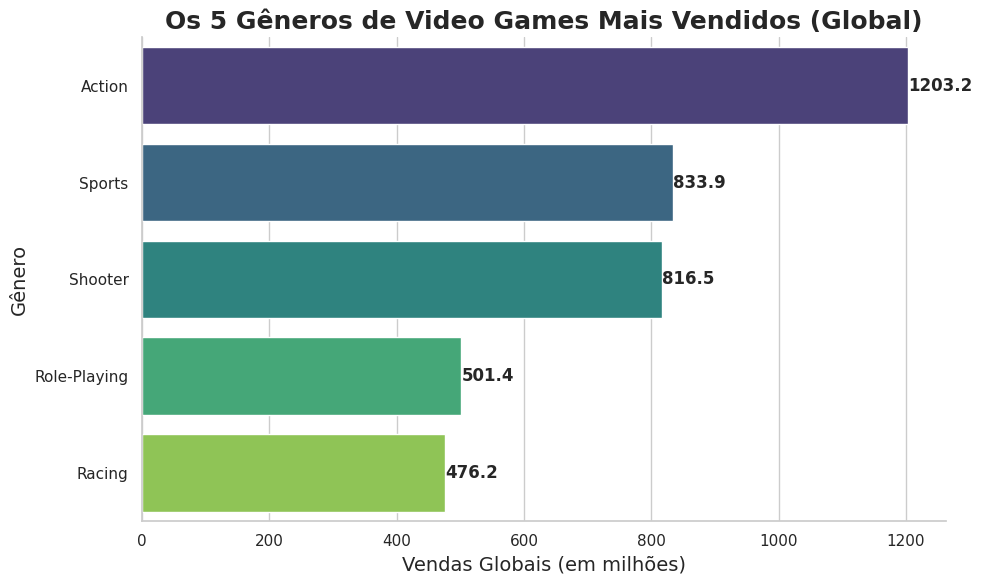

In [ ]:
# 5 Gêneros de Video Games Mais Vendidos

# Preparando os dados: Top 5 Gêneros
top5_genres = df_clean.groupby('Genre')['Global_Sales'].sum().sort_values(ascending=False).head(5)

# Criando o gráfico
plt.figure(figsize=(10,6))
sns.set_style('whitegrid')

# Gráfico de barras horizontal
sns.barplot(
    x=top5_genres.values,
    y=top5_genres.index,
    palette='viridis'
)

# Adicionando os valores nas barras
for i, value in enumerate(top5_genres.values):
    plt.text(value + 0.5, i, f'{value:.1f}', va='center', fontweight='bold', fontsize=12)

# Títulos e labels
plt.title('Os 5 Gêneros de Video Games Mais Vendidos (Global)', fontsize=18, fontweight='bold')
plt.xlabel('Vendas Globais (em milhões)', fontsize=14)
plt.ylabel('Gênero', fontsize=14)

# Removendo bordas
sns.despine()

# Layout ajustado
plt.tight_layout()
plt.show()


- Action é o gênero mais vendido globalmente (1203M), mostrando forte apelo popular.

- Sports e Shooter também têm alto desempenho, impulsionados por lançamentos frequentes e multiplayer online.

- RPGs e Racing mantêm vendas consistentes com base de fãs fiel.

- Gêneros com lançamentos regulares (ex: esportes) tendem a vender mais.

- A variedade de gêneros mostra um mercado diverso e segmentado.

### Gêneros com maiores notas da crítica

In [ ]:
# Remover valores nulos na nota da crítica
df_scores = df_clean.dropna(subset=['Critic_Score'])

# Ordenar do maior para o menor
top_10_scores = df_scores.sort_values(by='Critic_Score', ascending=False).head(10)

# Exibir os dados relevantes
top_10_scores[['Name', 'Platform', 'Year_of_Release', 'Critic_Score', 'Global_Sales']]


,Name,Platform,Year_of_Release,Critic_Score,Global_Sales
57,Grand Theft Auto IV,PS3,2008.0,98.0,10.50
5350,SoulCalibur,DC,1999.0,98.0,0.34
227,Tony Hawk's Pro Skater 2,PS,2000.0,98.0,4.68
51,Grand Theft Auto IV,X360,2008.0,98.0,11.01
97,Super Mario Galaxy 2,Wii,2010.0,97.0,7.51
129,Halo: Combat Evolved,XB,2001.0,97.0,6.43
23,Grand Theft Auto V,X360,2013.0,97.0,16.27
165,Grand Theft Auto V,XOne,2014.0,97.0,5.48
42,Grand Theft Auto V,PS4,2014.0,97.0,12.61
249,Tony Hawk's Pro Skater 3,PS2,2001.0,97.0,4.41


<ipython-input-22-11447659>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


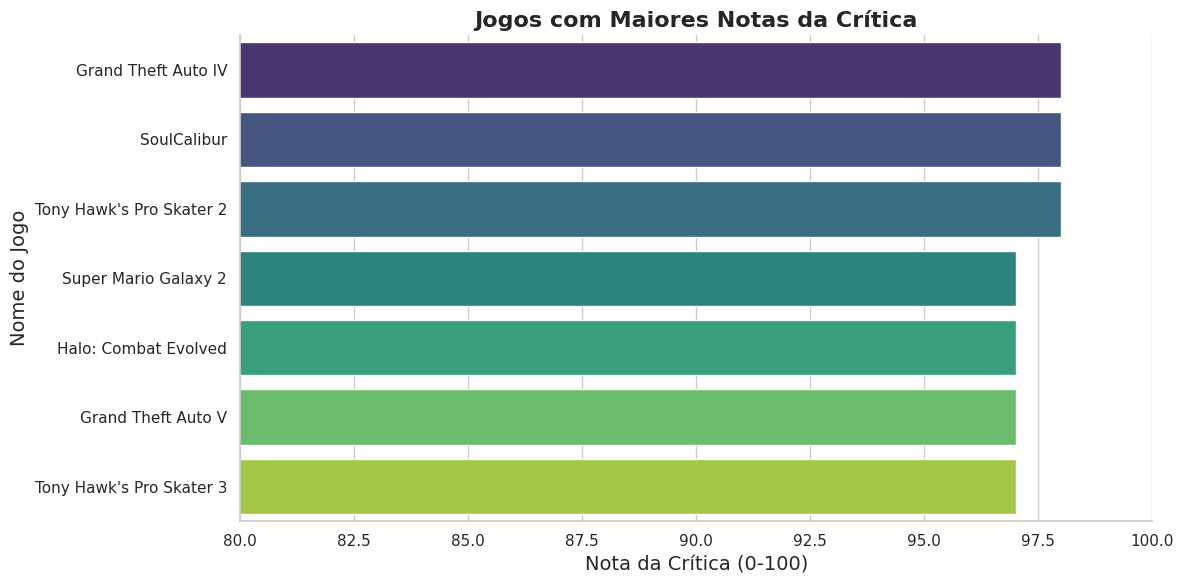

In [ ]:
plt.figure(figsize=(12,6))
sns.set_style('whitegrid')

# Criar gráfico de barras horizontais
sns.barplot(
    x='Critic_Score',
    y='Name',
    data=top_10_scores,
    palette='viridis'
)

plt.title('Jogos com Maiores Notas da Crítica', fontsize=16, fontweight='bold')
plt.xlabel('Nota da Crítica (0-100)', fontsize=14)
plt.ylabel('Nome do Jogo', fontsize=14)
plt.xlim(80, 100)  # Para dar foco nas notas altas

sns.despine()
plt.tight_layout()
plt.show()


Foi realizada uma análise para identificar os jogos com as maiores notas dadas pela crítica especializada (Critic_Score). O gráfico gerado mostra os 10 jogos mais bem avaliados do dataset, junto com suas respectivas notas. Isso permite observar quais títulos foram mais aclamados pela crítica e se há correlação com suas vendas globais.

- Jogos aclamados são majoritariamente de franquias conhecidas e consolidadas.

- Grand Theft Auto IV lidera, mostrando o impacto da narrativa e mundo aberto.

- Diversidade de gêneros: ação, esporte, luta, aventura — indica qualidade reconhecida além do gênero.

- Plataformas variadas, mostrando que qualidade crítica não está limitada a um único console.

- Jogos lançados nos anos 2000 dominam, indicando um pico na excelência de desenvolvimento técnico e criativo.

### Média de vendas por classificação etária

In [ ]:
# Média de vendas por classificação etária
df_clean.groupby('Rating')['Global_Sales'].mean().sort_values(ascending=False)


,Global_Sales
Rating,
AO,1.950000
K-A,1.920000
M,0.994962
E,0.941162
E10+,0.581237
T,0.579436
RP,0.030000


### AO	"Adults Only" (Somente Adultos)
K-A	"Kids to Adults" (Crianças a Adultos)
M	"Mature" (17 anos ou mais)
E	"Everyone" (Para todos)
E10+	"Everyone 10+" (10 anos ou mais)
T	"Teen" (Adolescente, 13 anos ou mais)
### RP	"Rating Pending" (Classificação pendente)

✅ Exemplo com Rating (variável categórica ordinal)



<ipython-input-24-4195322015>:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rating_avg_sales.values, y=rating_avg_sales.index, palette=colors[:len(rating_avg_sales)])


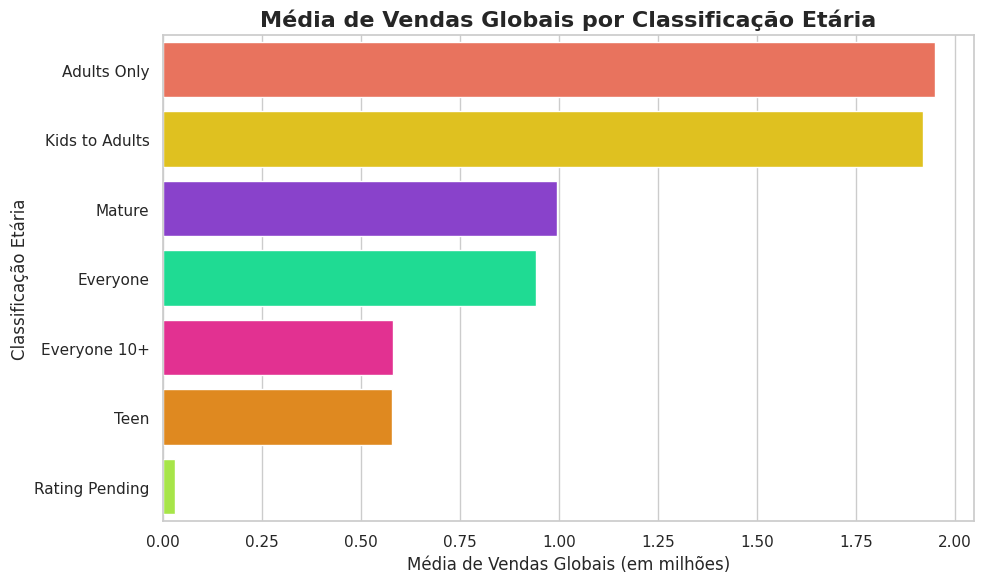

In [ ]:
# Mapeamento dos códigos de classificação etária
rating_map = {
    'E': 'Everyone',
    'T': 'Teen',
    'M': 'Mature',
    'E10+': 'Everyone 10+',
    'EC': 'Early Childhood',
    'K-A': 'Kids to Adults',
    'AO': 'Adults Only',
    'RP': 'Rating Pending',
    'NR': 'Not Rated'
}

# Calcular a média de vendas globais por classificação etária
rating_avg_sales = df_clean.groupby('Rating')['Global_Sales'].mean()

# Manter apenas os ratings que existem no DataFrame
valid_ratings = [r for r in rating_map if r in rating_avg_sales.index]
rating_avg_sales = rating_avg_sales.loc[valid_ratings]

# Renomear os índices para nomes completos
rating_avg_sales.index = [rating_map[r] for r in valid_ratings]

# Ordenar do maior para o menor
rating_avg_sales = rating_avg_sales.sort_values(ascending=False)

# Plot
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")
colors = ['#FF6347', '#FFD700', '#8A2BE2', '#00FA9A', '#FF1493', '#FF8C00', '#ADFF2F', '#20B2AA', '#D3D3D3']

sns.barplot(x=rating_avg_sales.values, y=rating_avg_sales.index, palette=colors[:len(rating_avg_sales)])

plt.title('Média de Vendas Globais por Classificação Etária', fontsize=16, fontweight='bold')
plt.xlabel('Média de Vendas Globais (em milhões)', fontsize=12)
plt.ylabel('Classificação Etária', fontsize=12)
plt.tight_layout()
plt.show()


- AO (Adults Only) e K-A (Kids to Adults) têm as maiores médias, mas podem refletir poucos jogos com vendas muito altas.

- Jogos classificados como M (Mature) e E (Everyone) têm boa média de vendas, indicando forte apelo comercial.

- E10+ e T vendem menos em média, apesar de grande volume no mercado.

- RP (Rating Pending) tem a menor média, o que é esperado por ser provisória.

### Quantidade de jogos por gênero

✅ Exemplo com Genre (variável categórica nominal)



<ipython-input-25-2594454585>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


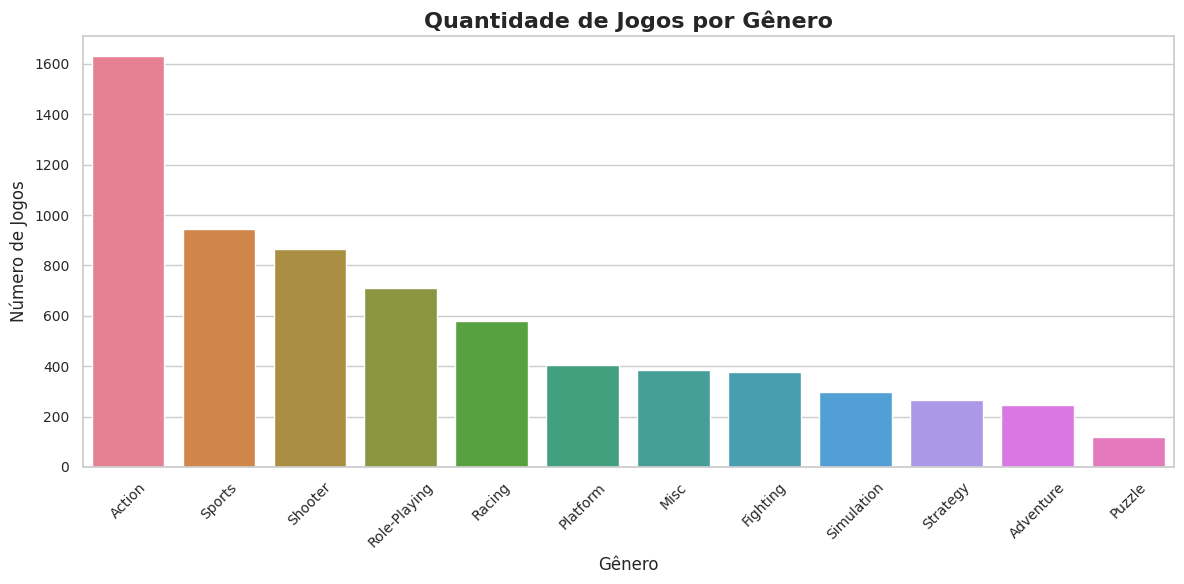

In [ ]:
# Preparar contagens
genre_counts = df_clean['Genre'].value_counts()

# Gerar uma paleta com tantas cores quantos gêneros
palette = sns.color_palette('husl', n_colors=len(genre_counts))

# Plot
plt.figure(figsize=(12,6))
sns.set_theme(style='whitegrid')

sns.barplot(
    x=genre_counts.index,
    y=genre_counts.values,
    palette=palette
)

# Títulos e rótulos
plt.title('Quantidade de Jogos por Gênero', fontsize=16, fontweight='bold')
plt.xlabel('Gênero', fontsize=12)
plt.ylabel('Número de Jogos', fontsize=12)
plt.xticks(rotation=45, fontsize=10)
plt.yticks(fontsize=10)

# Layout
plt.tight_layout()
plt.show()



O gênero Action lidera em quantidade de jogos lançados, seguido por Sports e Shooter, indicando foco da indústria em gêneros de alto apelo comercial. Gêneros como Strategy, Simulation e Adventure têm menos lançamentos, sugerindo nichos menores ou maior complexidade de produção.

### Plataformas com mais jogos de sucesso

<ipython-input-26-3988092325>:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sucesso_por_plataforma.values, y=sucesso_por_plataforma.index, palette='magma')


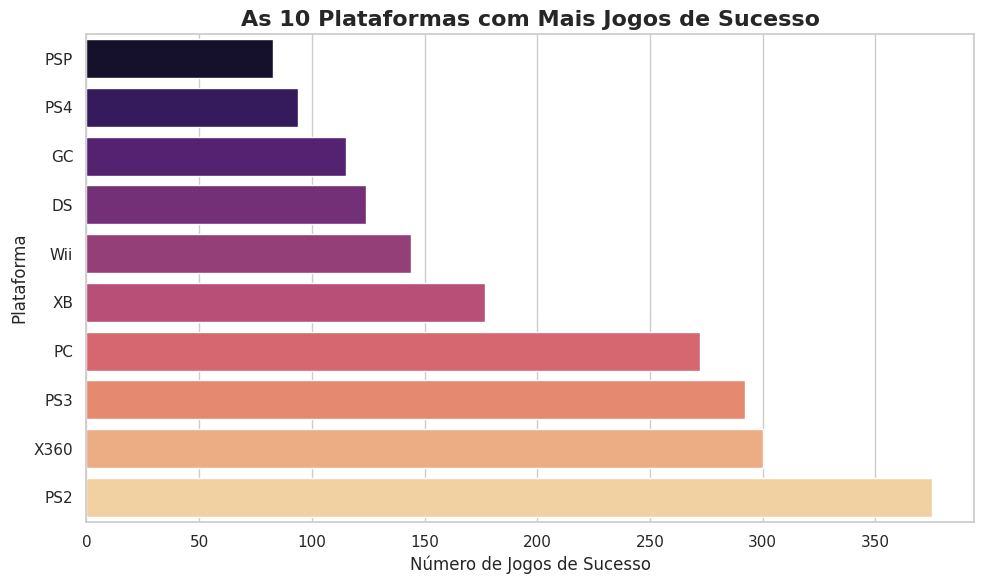

In [ ]:
# Definir jogos de sucesso
jogos_sucesso = df_clean[
    (df_clean['Critic_Score'] > 80) |
    (df_clean['Global_Sales'] > 1.0)
]

# Contar número de jogos de sucesso por plataforma
sucesso_por_plataforma = jogos_sucesso['Platform'].value_counts().head(10).sort_values(ascending=True)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=sucesso_por_plataforma.values, y=sucesso_por_plataforma.index, palette='magma')
plt.title('As 10 Plataformas com Mais Jogos de Sucesso', fontsize=16, fontweight='bold')
plt.xlabel('Número de Jogos de Sucesso')
plt.ylabel('Plataforma')
plt.tight_layout()
plt.show()


A PS2 lidera com o maior número de jogos de sucesso, seguida por X360 e PS3, mostrando o domínio das plataformas da Sony e Microsoft na era dos consoles entre 2000 e 2010. A presença do PC também destaca sua força contínua. Já plataformas como PSP e GC têm menos títulos de sucesso, indicando menor impacto comercial ou catálogo mais limitado.

### Média da Nota da Crítica por Ano de Lançamento

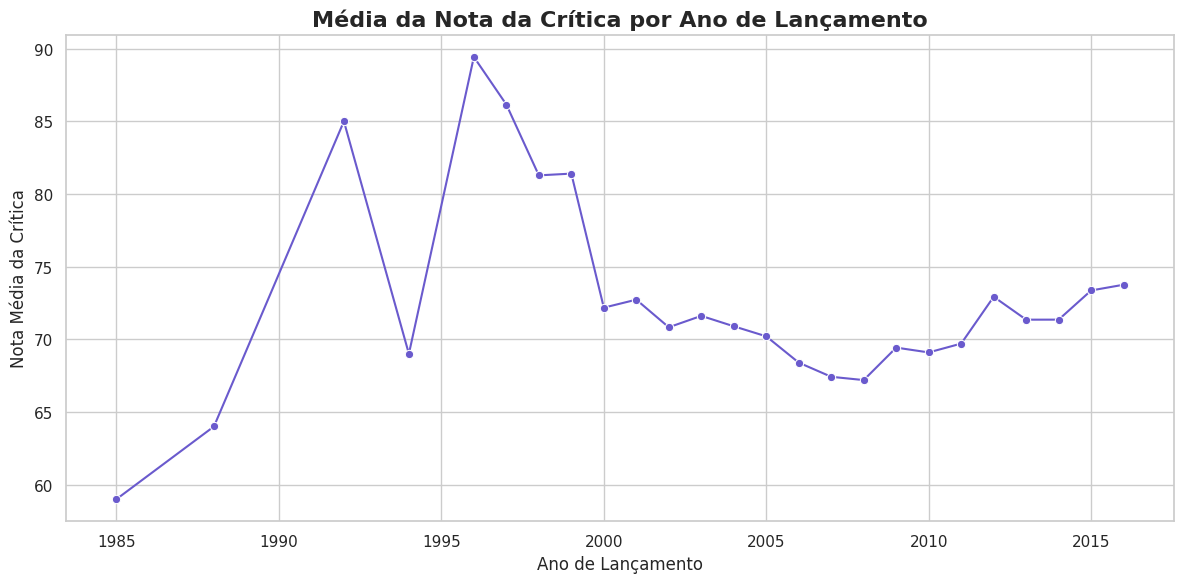

In [ ]:
# Selecionar anos e notas válidas
notas_ano = df_clean.dropna(subset=['Year_of_Release', 'Critic_Score'])

# Agrupar por ano e calcular a média da nota da crítica
media_nota_ano = notas_ano.groupby('Year_of_Release')['Critic_Score'].mean().reset_index()

# Plot
plt.figure(figsize=(12, 6))
sns.lineplot(x='Year_of_Release', y='Critic_Score', data=media_nota_ano, marker='o', color='slateblue')
plt.title('Média da Nota da Crítica por Ano de Lançamento', fontsize=16, fontweight='bold')
plt.xlabel('Ano de Lançamento')
plt.ylabel('Nota Média da Crítica')
plt.grid(True)
plt.tight_layout()
plt.show()


A média da nota da crítica cresceu até o início dos anos 2000, atingindo o pico por volta de 2005, indicando um período de alta qualidade ou maior exigência nos lançamentos. Após isso, há uma leve queda na média, o que pode refletir maior volume de jogos medianos, mudanças no mercado ou críticas mais rigorosas nos anos recentes.

### Distribuição dos Gêneros de Video Games e Vendas globais

Frequência dos Gêneros:
 Genre
Action          1630
Sports           943
Shooter          864
Role-Playing     712
Racing           581
Platform         403
Misc             384
Fighting         378
Simulation       297
Strategy         267
Adventure        248
Puzzle           118
Name: count, dtype: int64


<ipython-input-28-4222906814>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_counts.index, y=genre_counts.values, palette='viridis')


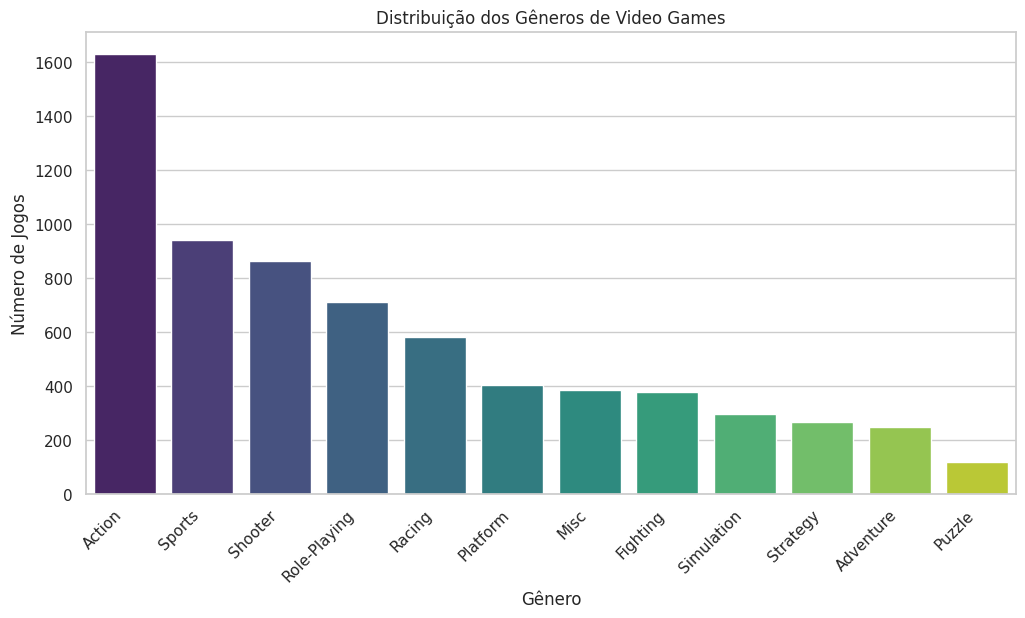


Vendas Globais por Gênero:
 Genre
Action          1203.16
Sports           833.85
Shooter          816.48
Role-Playing     501.37
Racing           476.22
Misc             416.26
Platform         377.80
Fighting         249.95
Simulation       202.70
Adventure         80.75
Puzzle            78.90
Strategy          69.61
Name: Global_Sales, dtype: float64


<ipython-input-28-4222906814>:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_sales.index, y=genre_sales.values, palette='magma')


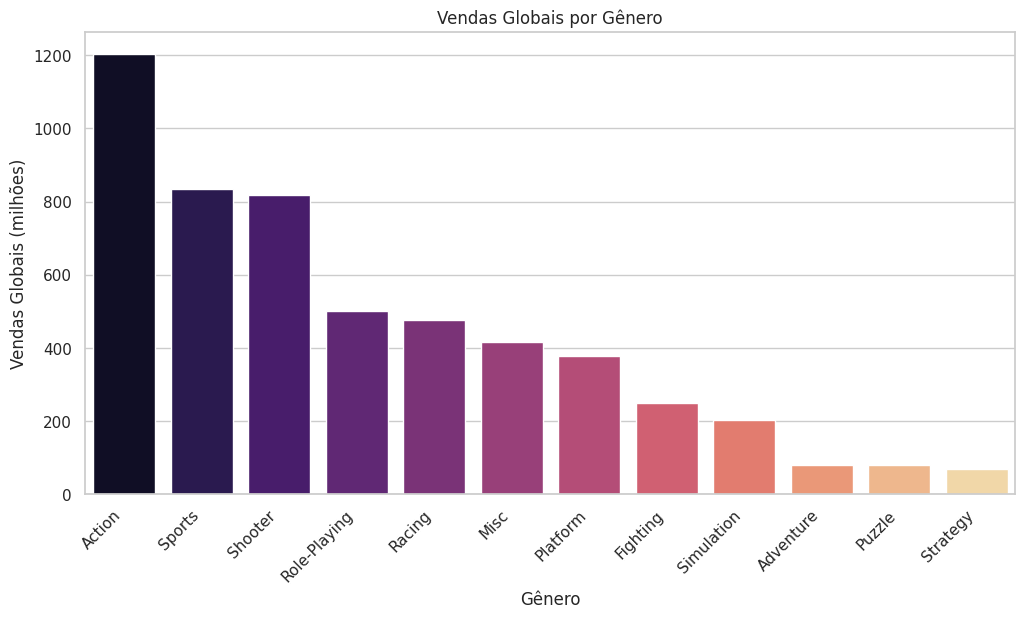

In [ ]:
# Contar a frequência de cada gênero
genre_counts = df_clean['Genre'].value_counts()
print("Frequência dos Gêneros:\n", genre_counts)

# Visualizar a distribuição dos gêneros
plt.figure(figsize=(12, 6))
sns.barplot(x=genre_counts.index, y=genre_counts.values, palette='viridis')
plt.title('Distribuição dos Gêneros de Video Games')
plt.xlabel('Gênero')
plt.ylabel('Número de Jogos')
plt.xticks(rotation=45, ha='right')  # Rotacionar os rótulos para melhor legibilidade
plt.show()

# Vendas globais por gênero (exemplo de análise multivariada)
genre_sales = df_clean.groupby('Genre')['Global_Sales'].sum().sort_values(ascending=False)
print("\nVendas Globais por Gênero:\n", genre_sales)

plt.figure(figsize=(12, 6))
sns.barplot(x=genre_sales.index, y=genre_sales.values, palette='magma')
plt.title('Vendas Globais por Gênero')
plt.xlabel('Gênero')
plt.ylabel('Vendas Globais (milhões)')
plt.xticks(rotation=45, ha='right')
plt.show()

- Ação domina o mercado, com mais de 1200 milhões de unidades vendidas, mostrando ser o gênero preferido globalmente.

- Esportes e Shooter também apresentam vendas expressivas, indicando grande apelo competitivo e casual.

- Gêneros como Adventure e Simulation vendem consideravelmente menos, o que pode refletir nichos de mercado mais específicos.

- A categoria Misc (diversos) pode indicar jogos que não se encaixam perfeitamente em outros gêneros, mas ainda têm impacto comercial relevante.

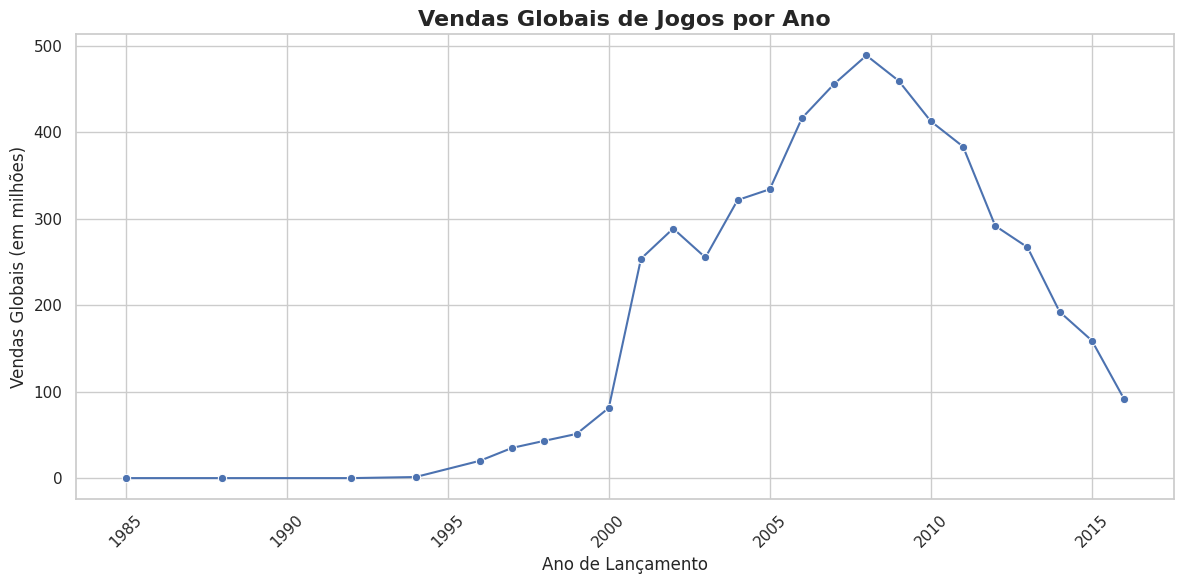

In [ ]:
df_year_sales = df_clean.groupby('Year_of_Release')['Global_Sales'].sum().dropna()

plt.figure(figsize=(12, 6))
sns.lineplot(x=df_year_sales.index.astype(int), y=df_year_sales.values, marker='o')

plt.title('Vendas Globais de Jogos por Ano', fontsize=16, fontweight='bold')
plt.xlabel('Ano de Lançamento', fontsize=12)
plt.ylabel('Vendas Globais (em milhões)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


As vendas globais de jogos cresceram consistentemente desde os anos 80, atingindo o pico entre 2008 e 2010, refletindo o auge das gerações PS3, Xbox 360 e Wii. Após esse período, observa-se uma queda gradual, possivelmente devido à transição para jogos digitais, mobile games ou mudanças no modelo de consumo.

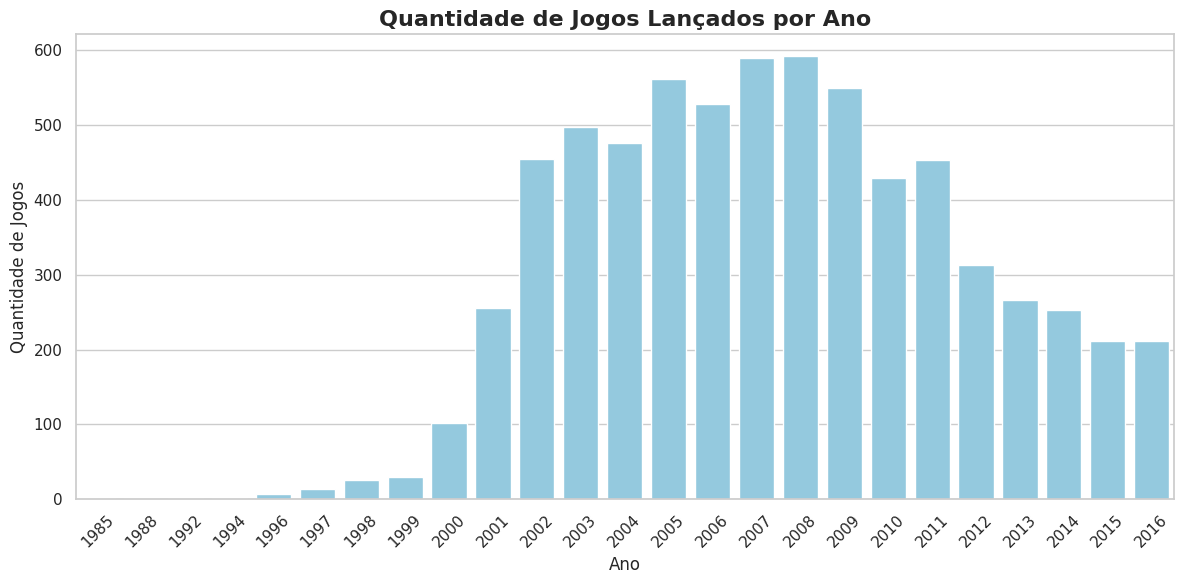

In [ ]:
df_year_count = df_clean['Year_of_Release'].dropna().astype(int).value_counts().sort_index()

plt.figure(figsize=(12, 6))
sns.barplot(x=df_year_count.index, y=df_year_count.values, color='skyblue')

plt.title('Quantidade de Jogos Lançados por Ano', fontsize=16, fontweight='bold')
plt.xlabel('Ano', fontsize=12)
plt.ylabel('Quantidade de Jogos', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


As vendas globais de jogos cresceram desde os anos 80, com pico entre 2008 e 2010, impulsionadas por PS3, Xbox 360 e Wii. Após isso, houve queda gradual, possivelmente pela migração para jogos digitais e mobile.

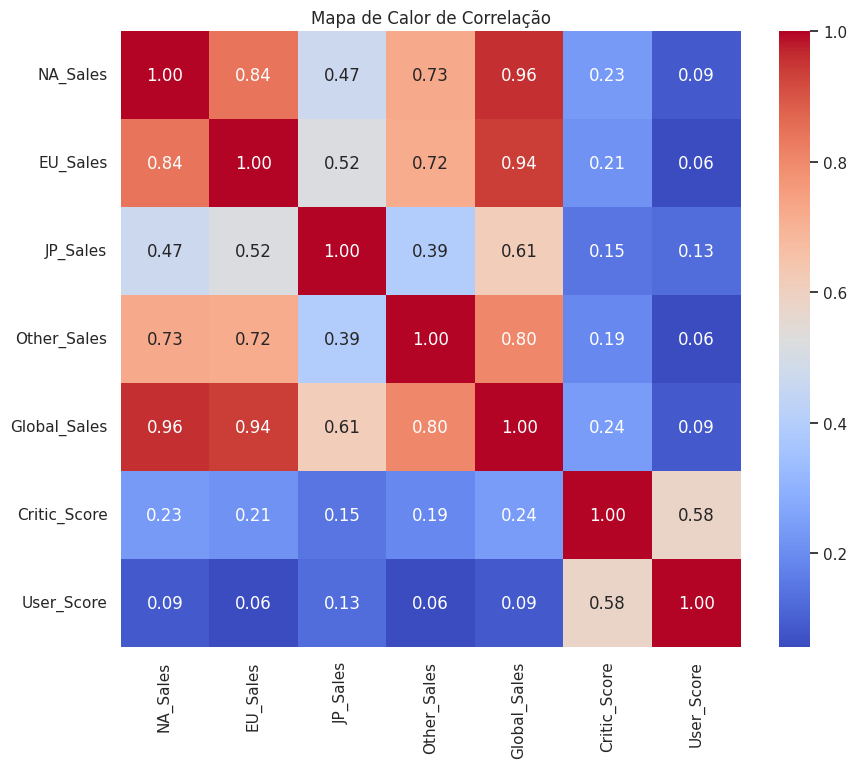

In [ ]:
#Análise de Correlação
# Selecionar apenas colunas numéricas de interesse
numeric_cols = df_clean[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales', 'Critic_Score', 'User_Score']]

# Calcular a matriz de correlação
corr_matrix = numeric_cols.corr()

# Plotar o heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Mapa de Calor de Correlação')
plt.show()

No mapa de calor, podemos verificar em destaque que:

- **Global_Sales x NA_Sales (0.96) e Global_Sales x EU_Sales (0.94):** Existe uma correlação quase perfeita entre as vendas na América do Norte/Europa e as vendas globais. As vendas nesses dois mercados são os principais impulsionadores do sucesso comercial de um jogo no mundo. Um jogo que vende bem na América do Norte ou na Europa, quase certamente terá altas vendas globais.

- **NA_Sales x EU_Sales (0.84):** As vendas entre a América do Norte e a Europa também são fortemente correlacionadas. Isso sugere que os gostos dos consumidores nessas duas regiões são muito semelhantes. Jogos que são populares em um mercado tendem a ser populares no outro.

- **Global_Sales x JP_Sales (0.61):** A correlação das vendas do Japão com as vendas globais é apenas moderada. Este é um ponto muito interessante. Mostra que, embora o Japão seja um mercado importante, seu comportamento é mais independente do que o do resto do mundo. Existem jogos que são um sucesso massivo no Japão, mas não no ocidente (e vice-versa). Isso indica uma diferença cultural significativa nos gostos para video games.

# Principais Insights da Análise Exploratória


### Distribuição das vendas globais

As vendas de jogos variam bastante entre regiões. A América do Norte lidera em volume, seguida pela Europa e Japão. Jogos com maior apelo global geralmente pertencem a franquias consolidadas.

### Editoras mais lucrativas

Editoras como Nintendo, Electronic Arts e Activision lideram as vendas globais. A Nintendo se destaca especialmente com franquias exclusivas.

### Plataformas com mais lançamentos

As plataformas PS2, DS, PS3 e Wii aparecem com maior número de jogos lançados. Isso reflete seu sucesso comercial e longa duração no mercado.

### Tendência temporal da crítica

A média das notas da crítica (Critic Score) teve oscilações ao longo dos anos. Alguns períodos mostram maior exigência ou melhora nos padrões de qualidade dos jogos.

### Avaliações por plataforma

Algumas plataformas como PS4 e Xbox One apresentam notas médias mais altas da crítica, sugerindo uma curadoria melhor ou jogos de maior orçamento.

### Gêneros mais frequentes e bem Avaliados
Gêneros como Action, Sports e Role-Playing são os mais comuns. No entanto, Role-Playing e Adventure tendem a ter melhores notas da crítica.

### Relação entre crítica e vendas
Apesar de uma leve correlação positiva, nem sempre jogos bem avaliados vendem mais — indicando que fatores como marketing, franquia e nostalgia influenciam fortemente o desempenho comercial.

### Variação por ano
O número de lançamentos teve picos entre 2006 e 2010, coincidindo com o auge de consoles como PS2, Wii e DS.



Análise da matriz de correlação:

Vendas são Impulsionadas pelo Ocidente: O sucesso comercial de um jogo globalmente é fortemente determinado por suas vendas na América do Norte e na Europa. Esses dois mercados possuem gostos muito semelhantes entre si.

Japão é um Mercado Distinto: O mercado japonês tem preferências únicas. A correlação de suas vendas com as do resto do mundo é apenas moderada (0.61), indicando que os sucessos de lá nem sempre se repetem no ocidente, e vice-versa.

Qualidade Não Garante Vendas: Esta é a principal descoberta. A nota da crítica (correlação de 0.24 com vendas) e, especialmente, a nota dos usuários (correlação de 0.09) têm uma relação muito fraca com o sucesso de vendas de um jogo. Um jogo ser bem avaliado não significa que venderá bem.

Críticos e Usuários Concordam Moderadamente: As avaliações de críticos e jogadores têm uma concordância moderada (0.58), mostrando que, embora muitas vezes alinhem-se, também existem divergências significativas de opinião.